In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("final_cleaned_data.csv")
df.columns

Index(['company_names', 'cars_names', 'engines', 'cc_battery_capacity',
       'horsepower', 'total_speed', 'cars_prices', 'fuel_types', 'seats',
       'torque', 'engine_cc', 'battery_kwh', 'has_battery', 'has_engine',
       'vehicle_type', 'acceleration_0_100'],
      dtype='object')

In [75]:
df["price_segment"] = pd.cut(
    df["cars_prices"],
    bins=[
        0,
        50000,
        100000,
        250000,
        np.inf
    ],
    labels=[
        "Budget",
        "Mid-range",
        "Luxury",
        "Ultra-luxury"
    ]
)
print(df["price_segment"].value_counts())

df.groupby("price_segment", observed=True)[
    ["horsepower", "total_speed", "torque"]
].mean().round(2)


 


price_segment
Budget          731
Mid-range       281
Luxury          116
Ultra-luxury     85
Name: count, dtype: int64


,horsepower,total_speed,torque
price_segment,,,
Budget,190.11,194.24,286.97
Mid-range,376.19,220.57,670.29
Luxury,560.85,275.97,1233.07
Ultra-luxury,760.72,315.06,866.25


In [76]:
# Top 10 by Performance
df["Performance Score"] = (
    df["horsepower"].rank(pct=True,method="min")
    + df["torque"].rank(pct=True,method="min")
    + df["total_speed"].rank(pct=True,method="min")
    + (1 - df["acceleration_0_100"].rank(pct=True,method="min"))
)
df[["company_names","cars_names","Performance Score"]].sort_values(ascending=False,by="Performance Score").head(10)

,company_names,cars_names,Performance Score
665,Tesla,Roadster 2,3.979390
884,Bugatti,Bolide,3.978566
878,Bugatti,Chiron Super Sport,3.973619
885,Bugatti,Mistral,3.969497
882,Bugatti,Centodieci,3.966200
879,Bugatti,Chiron Sport,3.964551
881,Bugatti,Divo,3.961253
883,Bugatti,La Voiture Noire,3.960429
876,Bugatti,Chiron,3.960429
880,Bugatti,Chiron Noire,3.960429


Performance Analysis with respect to the Log Price

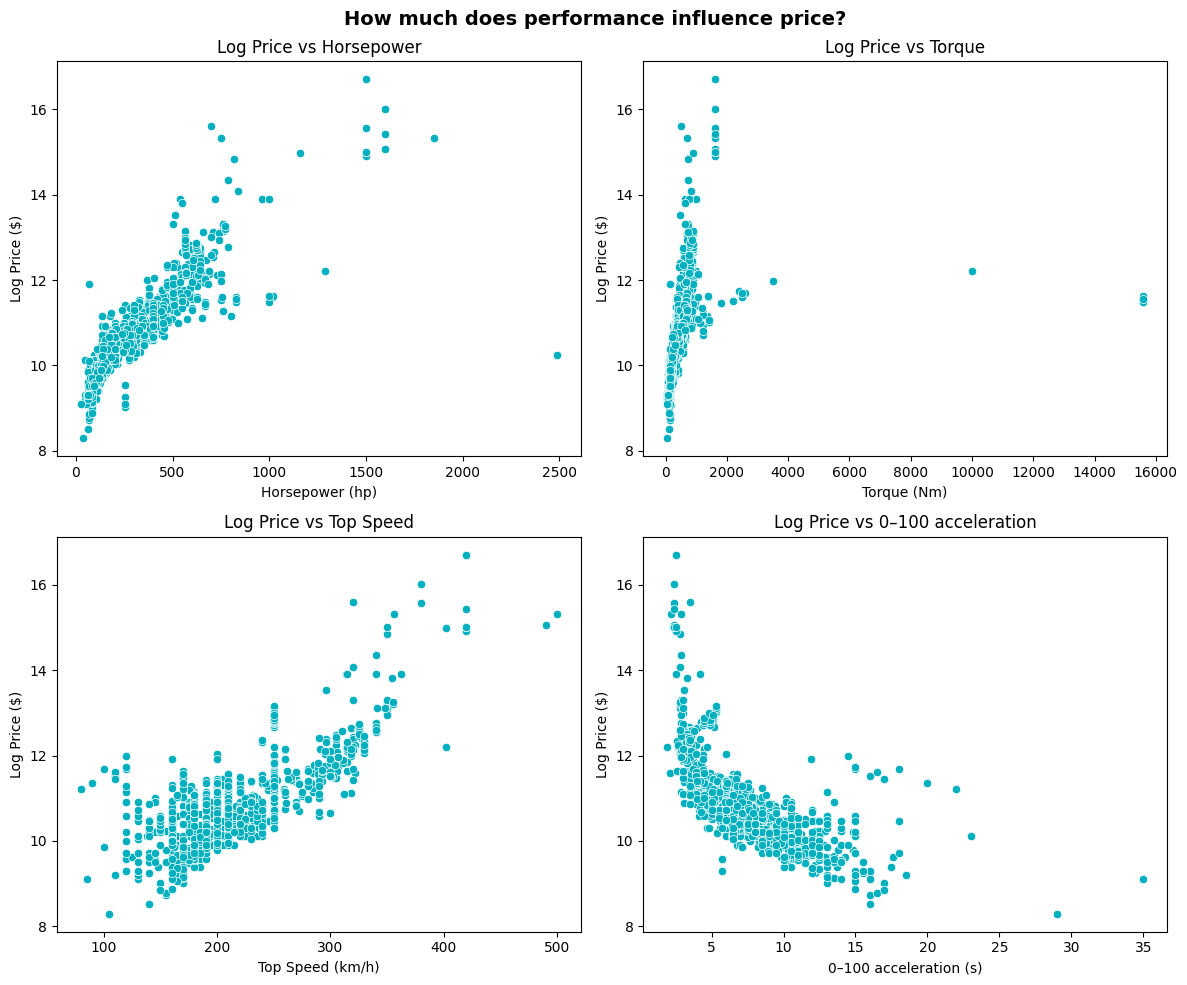

In [77]:
# How much does performance influence price

df["log_price"] = np.log1p(df["cars_prices"]) 

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# 1. Top-Left: Horsepower
sns.scatterplot(data=df, x="horsepower", y="log_price", color="#00b0be", ax=axs[0, 0])
axs[0, 0].set_xlabel("Horsepower (hp)")
axs[0, 0].set_ylabel("Log Price ($)")
axs[0, 0].set_title("Log Price vs Horsepower")

# 2. Top-Right: Torque
sns.scatterplot(data=df, x="torque", y="log_price", color="#00b0be", ax=axs[0, 1])
axs[0, 1].set_xlabel("Torque (Nm)")
axs[0, 1].set_ylabel("Log Price ($)")
axs[0, 1].set_title("Log Price vs Torque")

# 3. Bottom-Left: Top Speed
sns.scatterplot(data=df, x="total_speed", y="log_price", color="#00b0be", ax=axs[1, 0])
axs[1, 0].set_xlabel("Top Speed (km/h)")
axs[1, 0].set_ylabel("Log Price ($)")
axs[1, 0].set_title("Log Price vs Top Speed")

# 4. Bottom-Right: 0–100 Acceleration
sns.scatterplot(data=df, x="acceleration_0_100", y="log_price", color="#00b0be", ax=axs[1, 1])
axs[1, 1].set_xlabel("0–100 acceleration (s)")
axs[1, 1].set_ylabel("Log Price ($)")
axs[1, 1].set_title("Log Price vs 0–100 acceleration")

fig.suptitle("How much does performance influence price?", fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


Most Expensive Cars and Cars with the Top Speed 

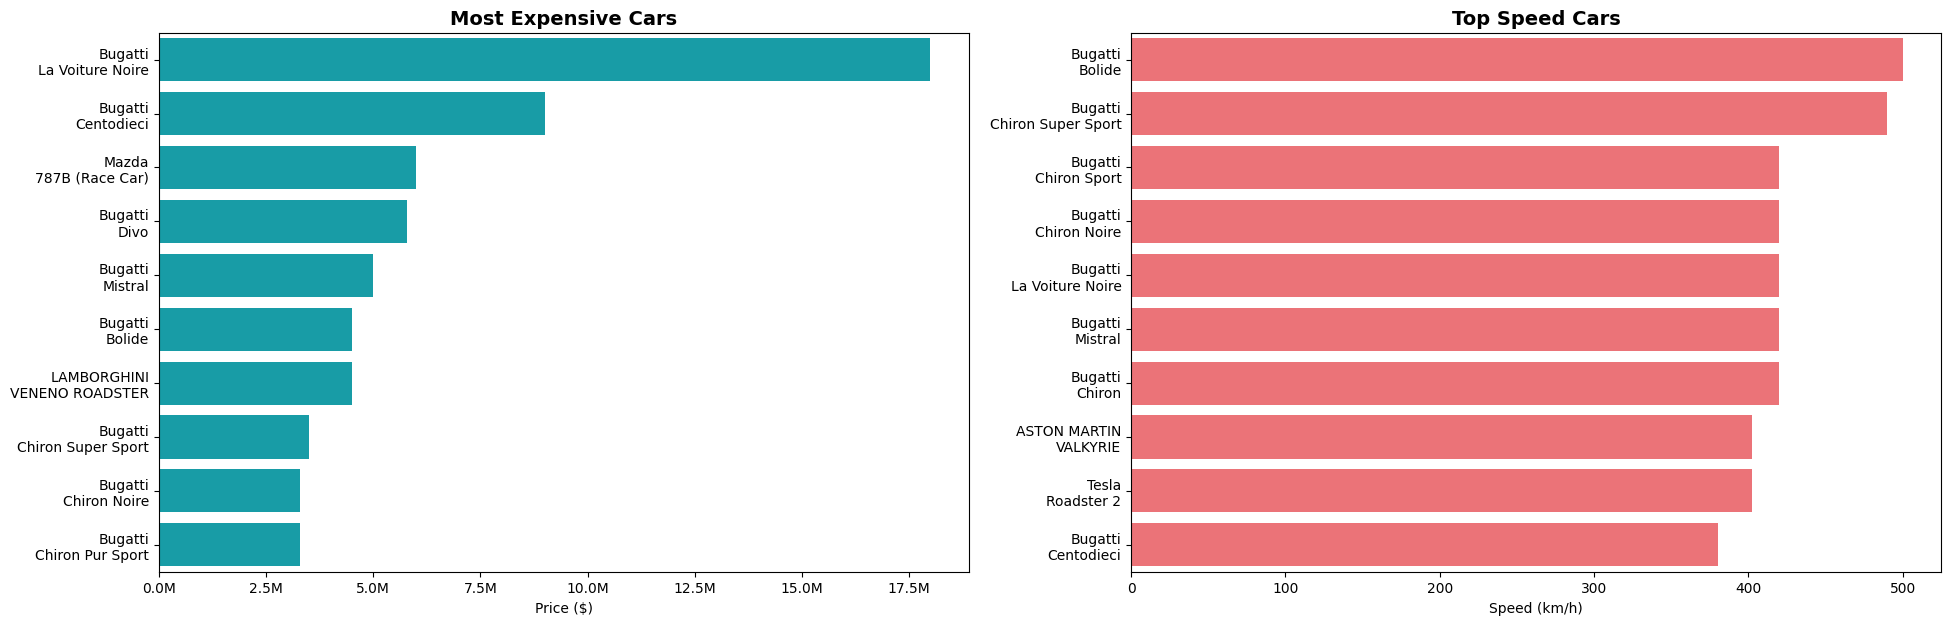

In [78]:
import matplotlib.ticker as ticker
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(23, 7))

most_expensive = df.sort_values("cars_prices", ascending=False).head(10).copy()
most_expensive["car_labels"] = most_expensive["company_names"] + "\n" + most_expensive["cars_names"]

sns.barplot(data=most_expensive, x="cars_prices", y="car_labels", color="#00b0be", ax=ax1)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x*1e-6:.1f}M"))
ax1.set_title("Most Expensive Cars", fontsize=14, fontweight="bold")
ax1.set_xlabel("Price ($)")
ax1.set_ylabel("")

top_speed = df.sort_values("total_speed", ascending=False).head(10).copy()
top_speed["car_labels"] = top_speed["company_names"] + "\n" + top_speed["cars_names"]

sns.barplot(data=top_speed, x="total_speed", y="car_labels", color="#ff5f66", ax=ax2)
ax2.set_title("Top Speed Cars", fontsize=14, fontweight="bold")
ax2.set_xlabel("Speed (km/h)")
ax2.set_ylabel("") 

plt.tight_layout
plt.show()


"Bang for the Buck": Price per Horsepower by Brand ($/hp)

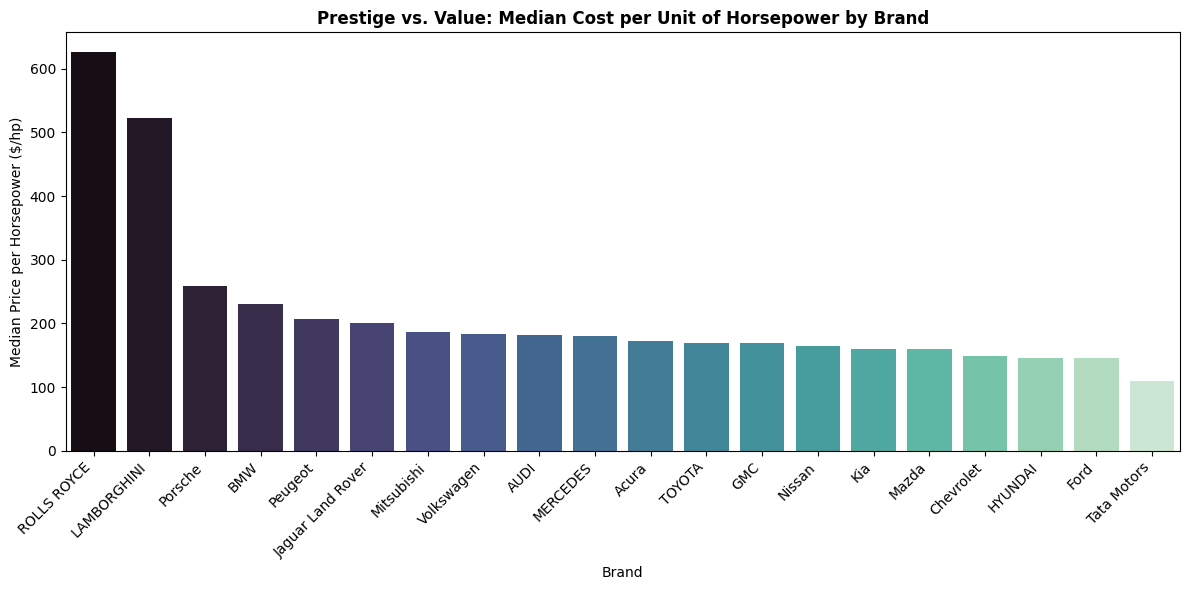

In [79]:
# Calculate cost per horsepower
df["price_per_hp"] = df["cars_prices"] / df["horsepower"]

# Filter for top 20 most frequent brands
top_brands = df["company_names"].value_counts().head(20).index
brand_stats = df[df["company_names"].isin(top_brands)].groupby("company_names")["price_per_hp"].median().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=brand_stats.index, y=brand_stats.values, hue=brand_stats.index, palette="mako", legend=False)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Median Price per Horsepower ($/hp)")
plt.xlabel("Brand")
plt.title("Prestige vs. Value: Median Cost per Unit of Horsepower by Brand", fontweight='bold')
plt.tight_layout()
plt.show()


EV vs. Hybrid vs. ICE: Acceleration vs. Top Speed Trade-off

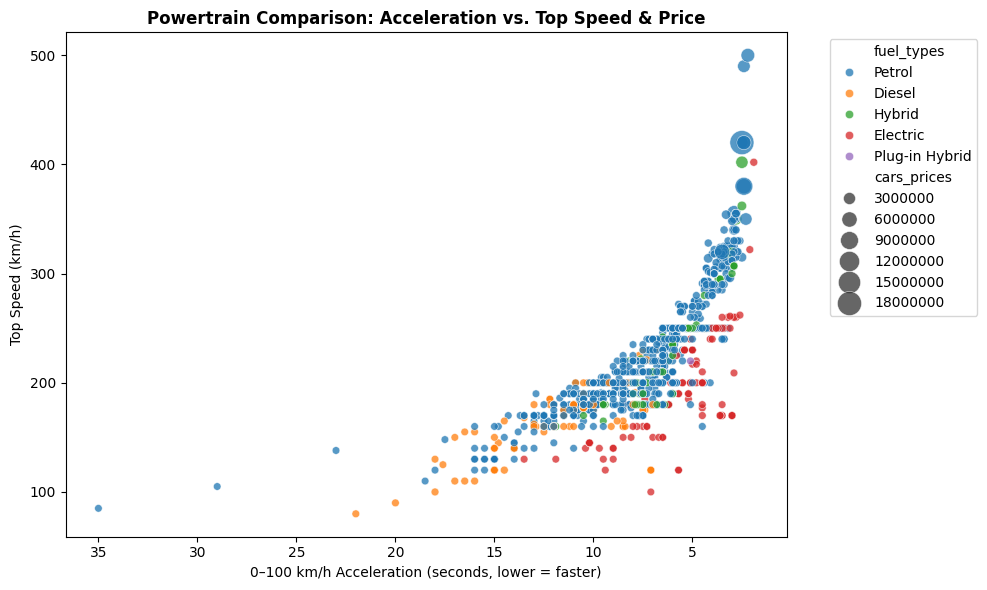

In [80]:
plt.figure(figsize=(10, 6))
# Filter main fuel categories
main_fuels = df[df["fuel_types"].isin(["Petrol", "Diesel", "Electric", "Hybrid", "Plug-in Hybrid"])]

sns.scatterplot(
    data=main_fuels,
    x="acceleration_0_100",
    y="total_speed",
    hue="fuel_types",
    size="cars_prices",
    sizes=(30, 300),
    alpha=0.75,
    palette="tab10"
)
plt.xlabel("0–100 km/h Acceleration (seconds, lower = faster)")
plt.ylabel("Top Speed (km/h)")
plt.title("Powertrain Comparison: Acceleration vs. Top Speed & Price", fontweight='bold')
plt.gca().invert_xaxis()  # Invert so faster acceleration is on the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Specific Output: Engine Efficiency (Horsepower per Liter)

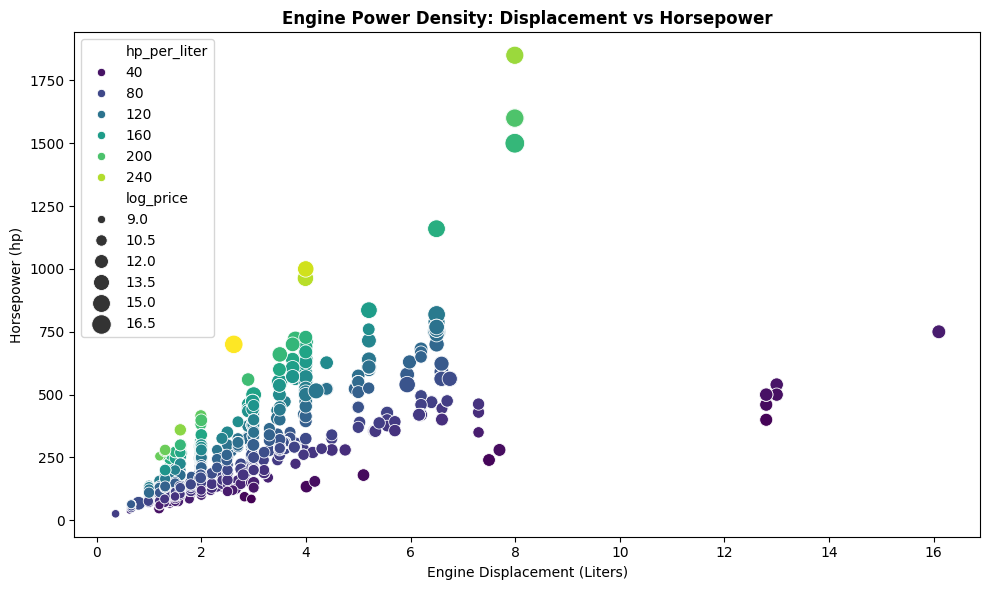

In [81]:
# Only for ICE/Hybrid with valid engine CC
ice_df = df[(df["has_engine"] == 1) & (df["engine_cc"] > 0)].copy()
ice_df["engine_liters"] = ice_df["engine_cc"] / 1000.0
ice_df["hp_per_liter"] = ice_df["horsepower"] / ice_df["engine_liters"]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=ice_df,
    x="engine_liters",
    y="horsepower",
    hue="hp_per_liter",
    palette="viridis",
    size="log_price",
    sizes=(20, 200)
)
plt.xlabel("Engine Displacement (Liters)")
plt.ylabel("Horsepower (hp)")
plt.title("Engine Power Density: Displacement vs Horsepower", fontweight='bold')
plt.tight_layout()
plt.show()


Practicality vs. Performance: Seating Capacity Analysis

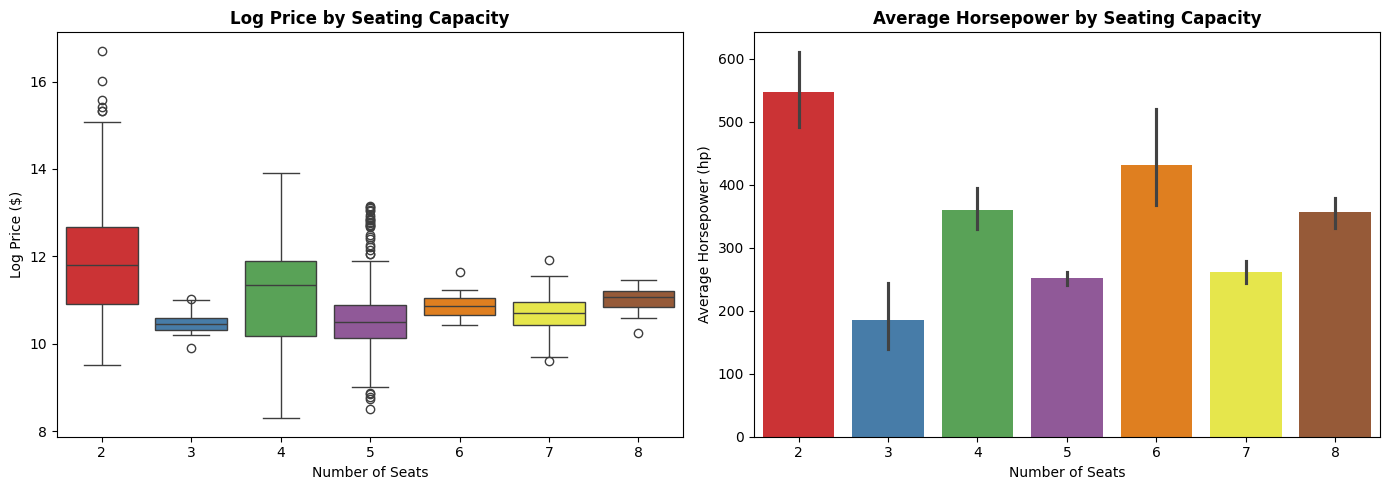

In [82]:
# Convert seats to numeric / clean categories
valid_seats = df[df["seats"].str.isnumeric().fillna(False)].copy()
valid_seats["seats"] = valid_seats["seats"].astype(int)
valid_seats = valid_seats[valid_seats["seats"].between(2, 8)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=valid_seats, x="seats", y="log_price", ax=ax1, hue="seats", palette="Set1", legend=False)
ax1.set_title("Log Price by Seating Capacity", fontweight='bold')
ax1.set_xlabel("Number of Seats")
ax1.set_ylabel("Log Price ($)")

sns.barplot(data=valid_seats, x="seats", y="horsepower", ax=ax2, hue="seats", palette="Set1", legend=False)
ax2.set_title("Average Horsepower by Seating Capacity", fontweight='bold')
ax2.set_xlabel("Number of Seats")
ax2.set_ylabel("Average Horsepower (hp)")

plt.tight_layout()
plt.show()


Multicollinearity & Feature Interaction (Hierarchical Cluster Heatmap)

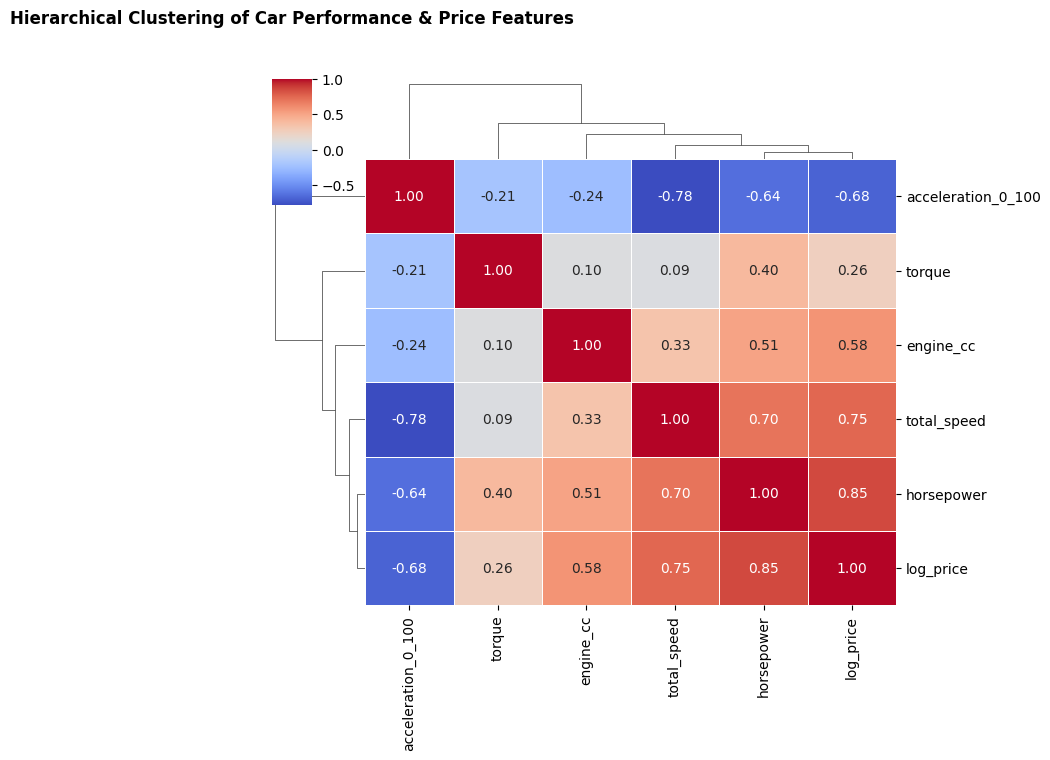

In [83]:
numeric_features = ["horsepower", "torque", "engine_cc", "total_speed", "acceleration_0_100", "log_price"]
corr_matrix = df[numeric_features].corr()

sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    figsize=(8, 7),
    linewidths=0.5,
    dendrogram_ratio=(0.15, 0.15)
)
plt.title("Hierarchical Clustering of Car Performance & Price Features", pad=40, fontweight='bold')
plt.show()
